## Exploratory Data Analysis: Colorectal Cancer Digital Pathology

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import medmnist
from medmnist import INFO

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

data_flag = 'pathmnist'
info = INFO[data_flag]
class_names = info['label']

DataClass = getattr(medmnist, info['python_class'])
train_dataset = DataClass(split='train', download=True)
test_dataset = DataClass(split='test', download=True)

X_train, y_train = train_dataset.imgs, train_dataset.labels.squeeze()
X_test, y_test = test_dataset.imgs, test_dataset.labels.squeeze()

tissue_labels = {
    0: 'Adipose', 1: 'Background', 2: 'Debris', 
    3: 'Lymphocytes', 4: 'Mucus', 5: 'Smooth Muscle', 
    6: 'Normal Colon', 7: 'Stroma', 8: 'Colorectal AdenoCA (Tumor)'
}

print(f"Training images: {X_train.shape}")
print(f"Testing images: {X_test.shape}")

100%|██████████| 206M/206M [03:12<00:00, 1.07MB/s] 


Training images: (89996, 28, 28, 3)
Testing images: (7180, 28, 28, 3)


## Class Distribution

/var/folders/yj/whx5_fpn08x4pjsxwg6ly3qw0000gn/T/ipykernel_2192/2731008247.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts, y=labels, ax=axes[0], palette="viridis")
/var/folders/yj/whx5_fpn08x4pjsxwg6ly3qw0000gn/T/ipykernel_2192/2731008247.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts, y=labels, ax=axes[1], palette="magma")


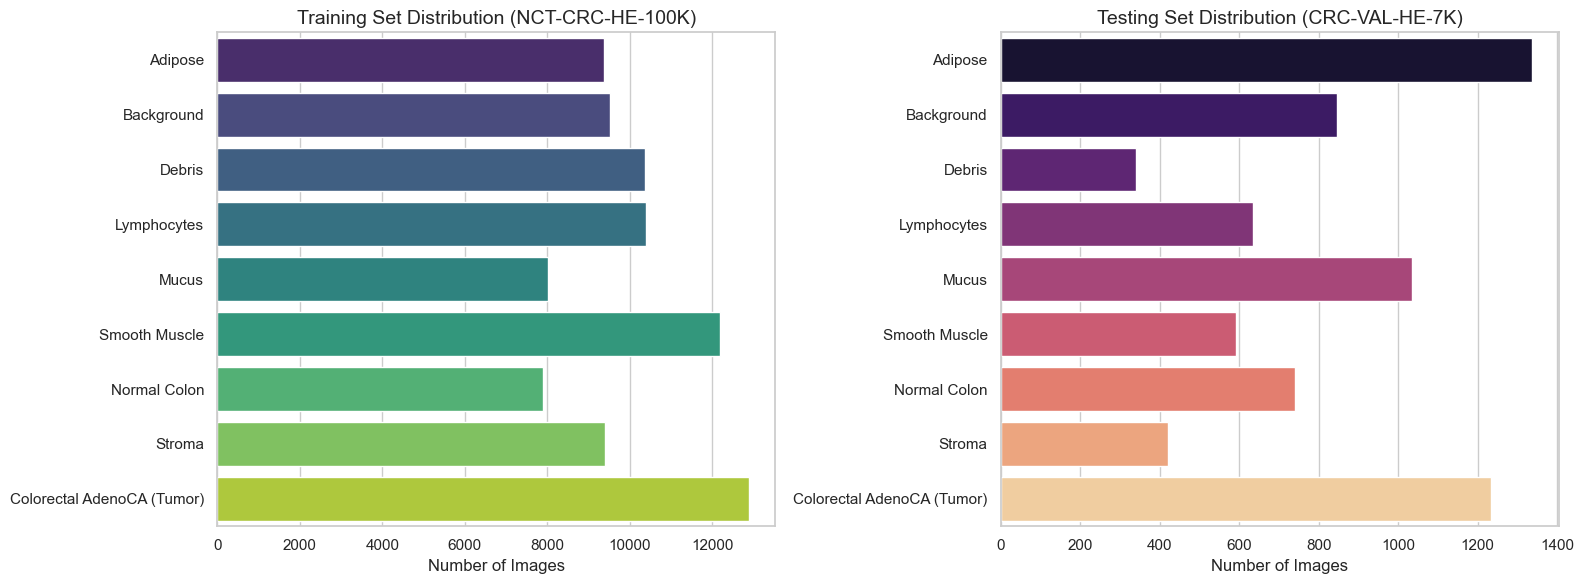

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_counts = [np.sum(y_train == i) for i in range(9)]
test_counts = [np.sum(y_test == i) for i in range(9)]
labels = [tissue_labels[i] for i in range(9)]

sns.barplot(x=train_counts, y=labels, ax=axes[0], palette="viridis")
axes[0].set_title("Training Set Distribution (NCT-CRC-HE-100K)", fontsize=14)
axes[0].set_xlabel("Number of Images")

sns.barplot(x=test_counts, y=labels, ax=axes[1], palette="magma")
axes[1].set_title("Testing Set Distribution (CRC-VAL-HE-7K)", fontsize=14)
axes[1].set_xlabel("Number of Images")

plt.tight_layout()
plt.show()

## Tissue Grid Visualization

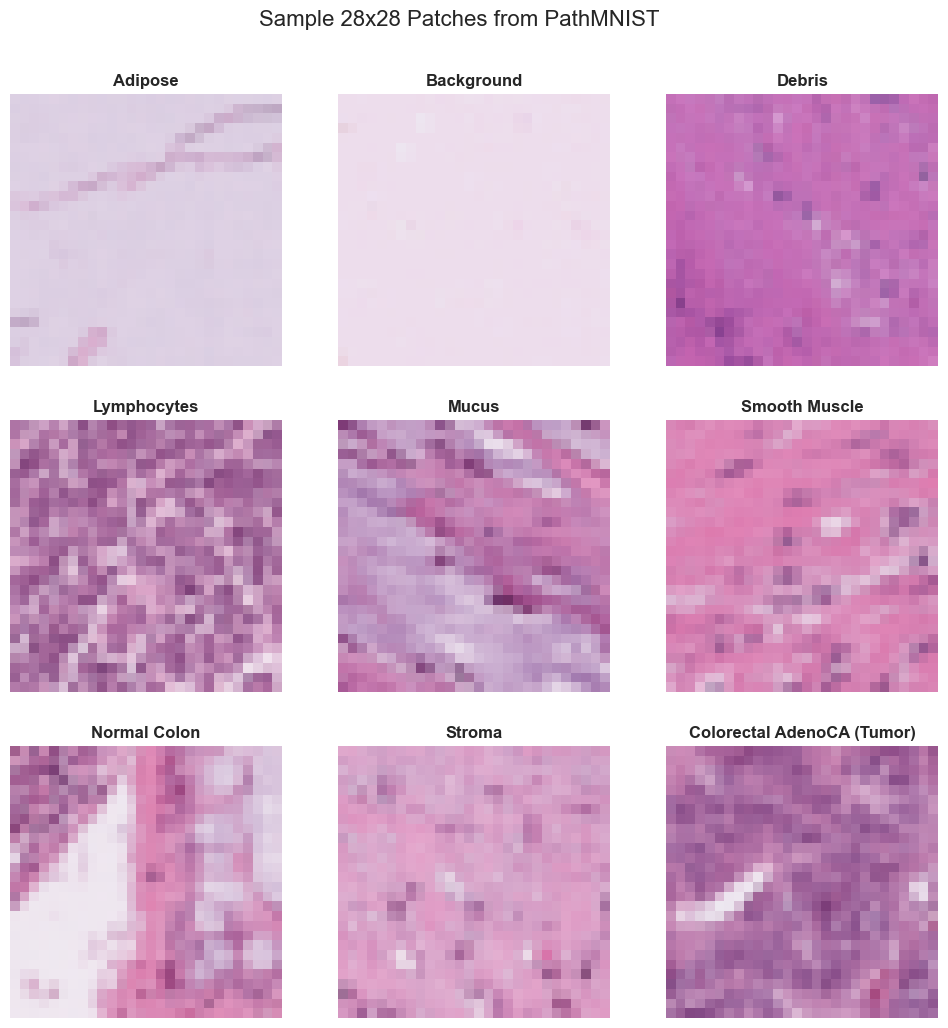

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    idx = np.where(y_train == i)[0][0]
    img = X_train[idx]
    
    axes[i].imshow(img)
    axes[i].set_title(tissue_labels[i], fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Sample 28x28 Patches from PathMNIST", fontsize=16, y=0.95)
plt.show()

## Hematoxylin and Eosin Stain Color Profiles (Normal vs. Tumor)

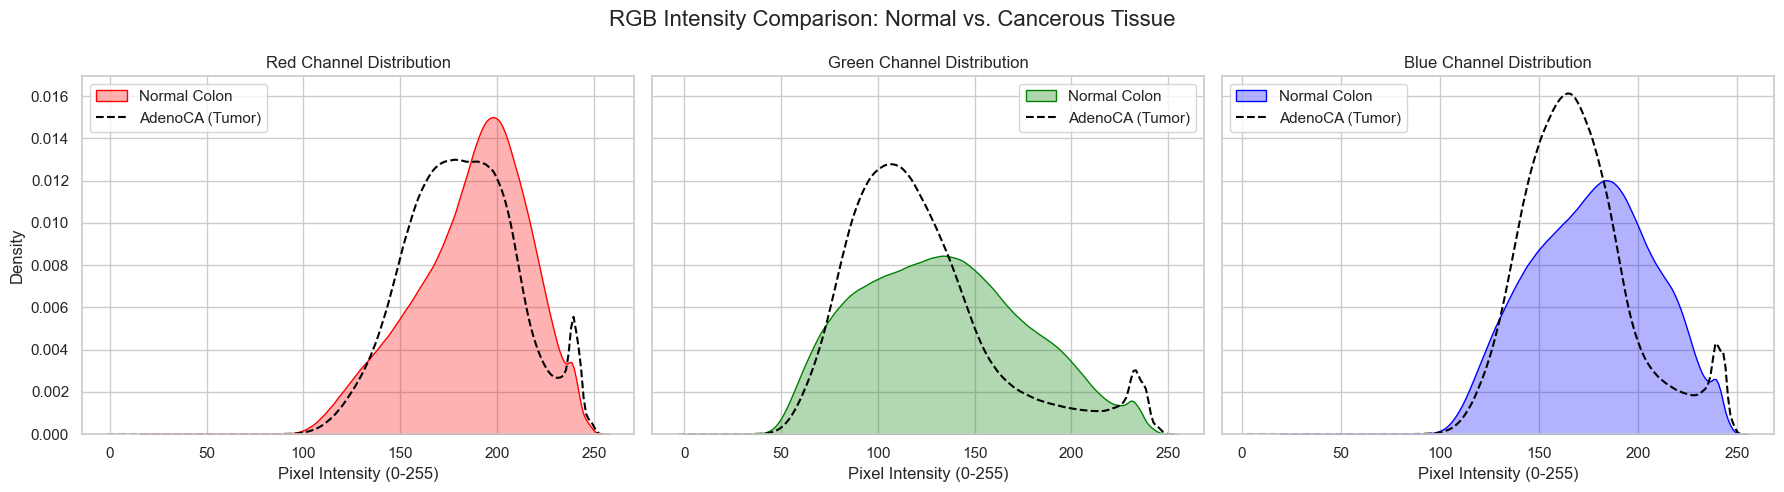

In [ ]:
normal_imgs = X_train[y_train == 6]
tumor_imgs = X_train[y_train == 8]

colors = ('Red', 'Green', 'Blue')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, color in enumerate(colors):
    normal_channel = normal_imgs[:, :, :, i].flatten()
    tumor_channel = tumor_imgs[:, :, :, i].flatten()
    
    sns.kdeplot(normal_channel, ax=axes[i], color=color.lower(), label='Normal Colon', fill=True, alpha=0.3)
    sns.kdeplot(tumor_channel, ax=axes[i], color='black', label='AdenoCA (Tumor)', fill=False, linestyle="--")
    
    axes[i].set_title(f"{color} Channel Distribution")
    axes[i].set_xlabel("Pixel Intensity (0-255)")
    axes[i].legend()

plt.suptitle("RGB Intensity Comparison: Normal vs. Cancerous Tissue", fontsize=16)
plt.tight_layout()
plt.show()

## 2D PCA Projection

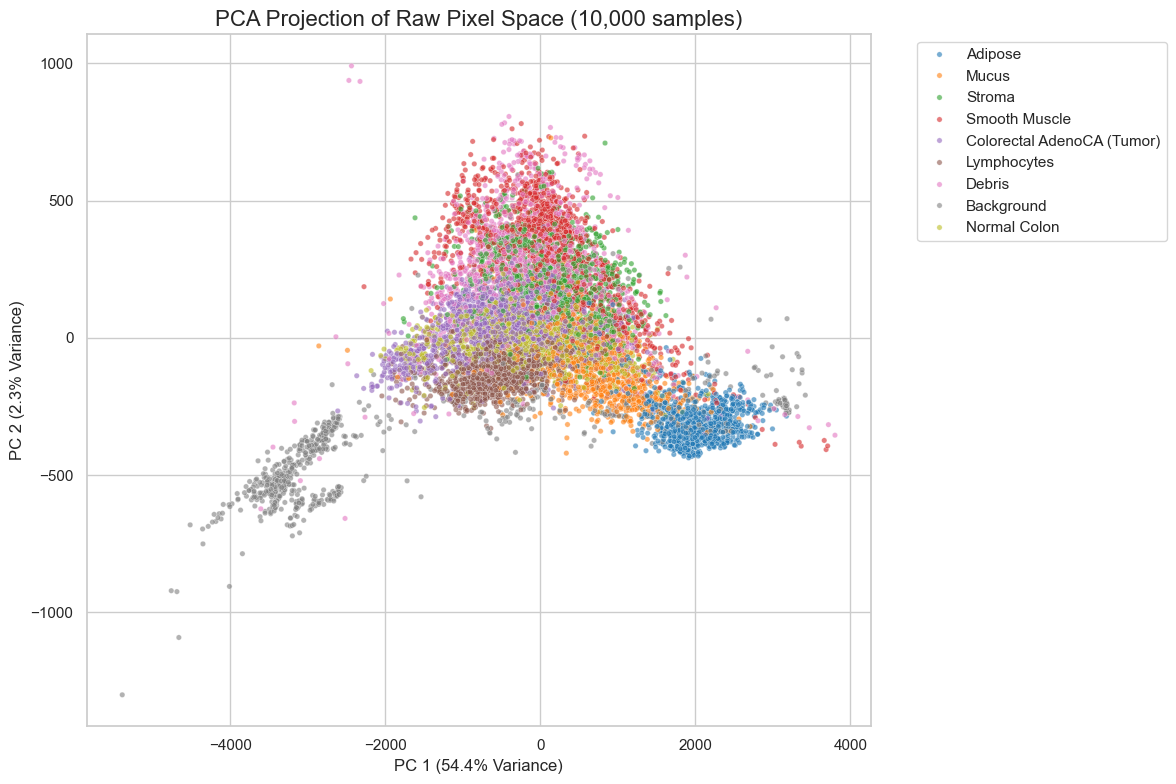

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd


n_samples = 10000
X_flat = X_train[:n_samples].reshape(n_samples, -1)
y_subset = y_train[:n_samples]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Tissue Class'] = [tissue_labels[label] for label in y_subset]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2',
    hue='Tissue Class',
    palette='tab10',
    data=pca_df,
    alpha=0.6,
    s=15
)

plt.title("PCA Projection of Raw Pixel Space (10,000 samples)", fontsize=16)
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

-> Initializing Standard Deep Learning Baseline: ResNet-18 (Adapted for 28x28)
Extracting feature embeddings...
Extraction complete. Latent space shape: (5000, 512)


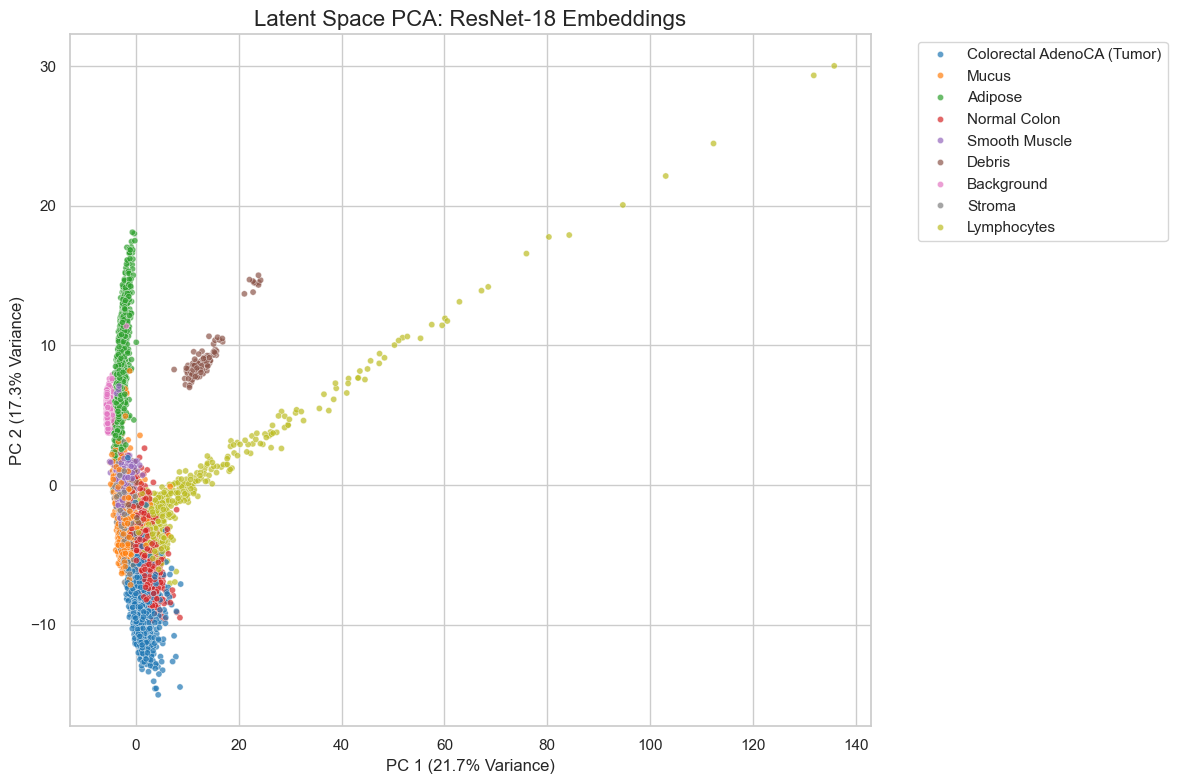

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.models import get_model

device = torch.device("mps")

model = get_model(model_name="resnet18", num_classes=9)

weights_path = "../runs/resnet18/run_20260527_173040/best_model.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

model.fc = nn.Identity()
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

n_samples = 5000
embeddings = []
labels_subset = y_test[:n_samples]

print("Extracting feature embeddings...")
with torch.no_grad():
    for i in range(n_samples):
        img = X_test[i]
        tensor_img = transform(img).unsqueeze(0).to(device)
        
        feature_vector = model(tensor_img)
        embeddings.append(feature_vector.cpu().numpy().flatten())

embeddings = np.array(embeddings)
print(f"Extraction complete. Latent space shape: {embeddings.shape}")

pca_latent = PCA(n_components=2)
X_latent_pca = pca_latent.fit_transform(embeddings)

pca_latent_df = pd.DataFrame(data=X_latent_pca, columns=['Latent PC 1', 'Latent PC 2'])
pca_latent_df['Tissue Class'] = [tissue_labels[label] for label in labels_subset]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Latent PC 1', 
    y='Latent PC 2',
    hue='Tissue Class',
    palette='tab10',
    data=pca_latent_df,
    alpha=0.7,
    s=20
)

plt.title("Latent Space PCA: ResNet-18 Embeddings", fontsize=16)
plt.xlabel(f"PC 1 ({pca_latent.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC 2 ({pca_latent.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Examples of misclassifications

-> Initializing Standard Deep Learning Baseline: ResNet-18 (Adapted for 28x28)
Running inference to find misclassifications...
Found 708 misclassified images out of 7180.


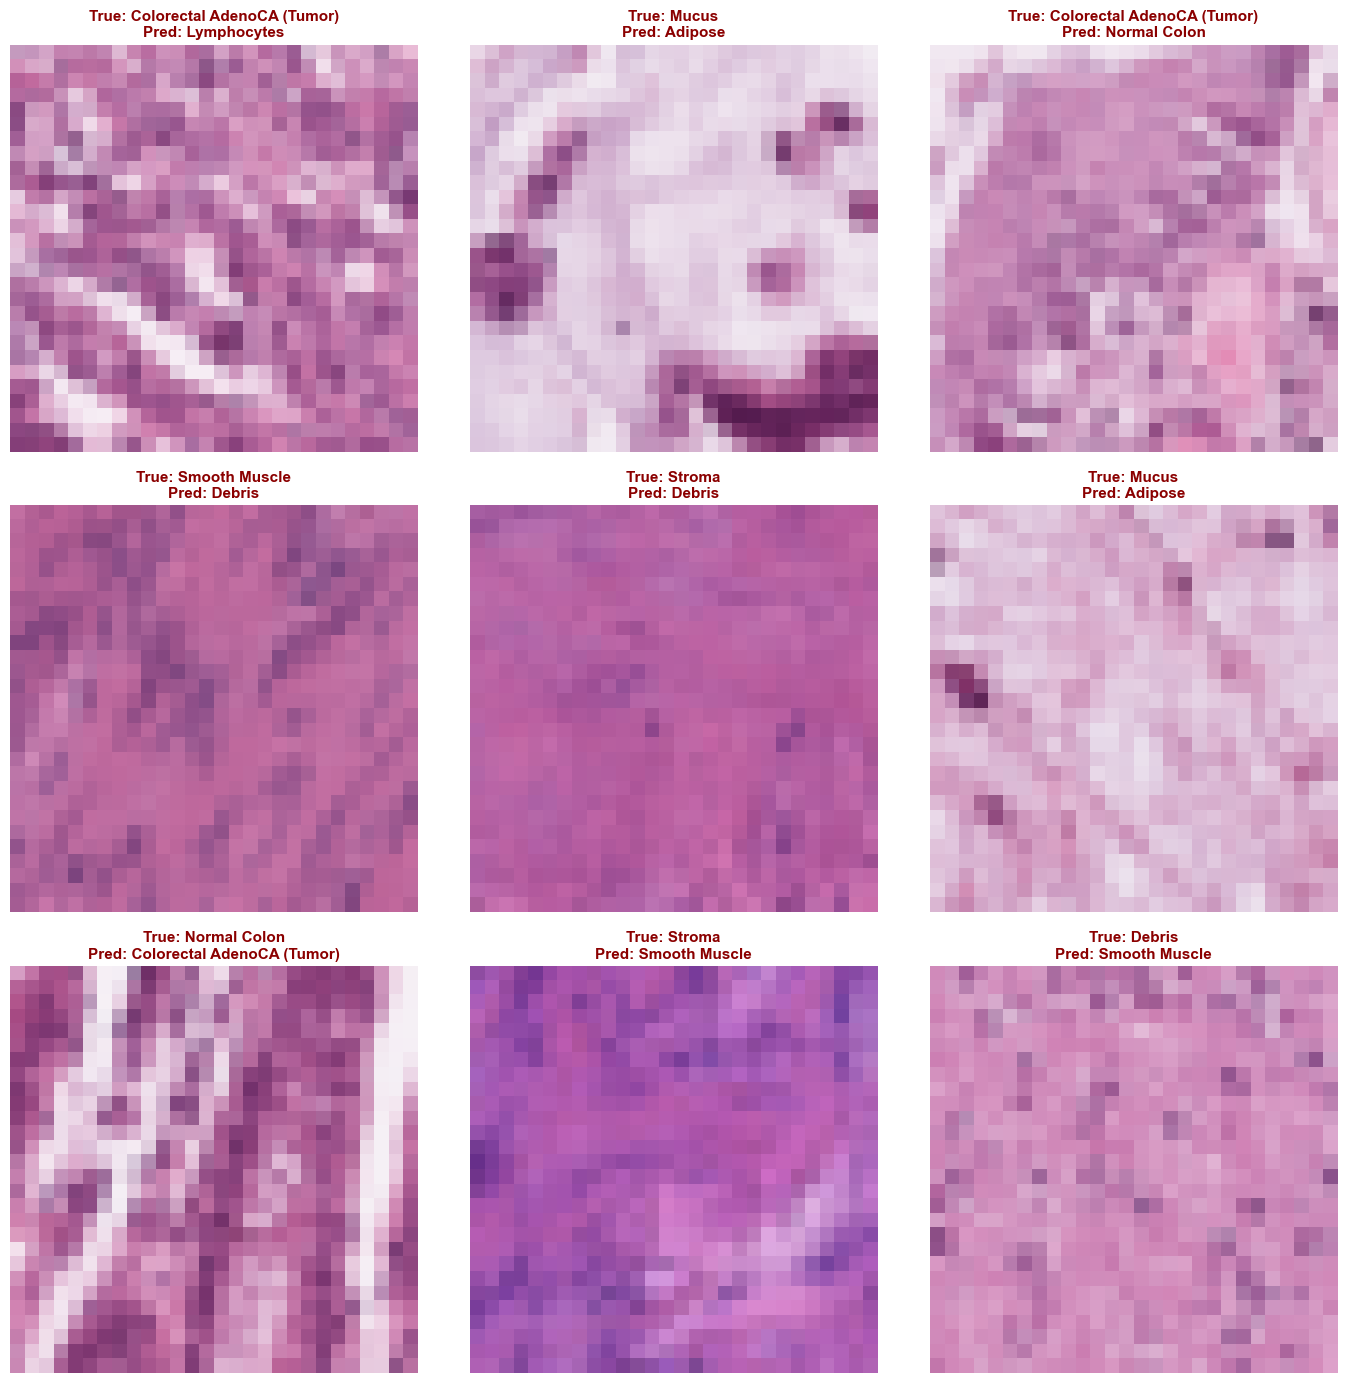

In [ ]:
model = get_model(model_name="resnet18", num_classes=9)
weights_path = "../runs/resnet18/run_20260527_173040/best_model.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))
model = model.to(device)
model.eval()

print("Running inference to find misclassifications...")

predictions = []
with torch.no_grad():
    for i in range(0, len(X_test), 64):
        batch_imgs = X_test[i:i+64]
        
        tensor_batch = torch.stack([transform(img) for img in batch_imgs]).to(device)
        
        outputs = model(tensor_batch)
        _, preds = outputs.max(1)
        predictions.extend(preds.cpu().numpy())

predictions = np.array(predictions)

incorrect_indices = np.where(predictions != y_test)[0]
print(f"Found {len(incorrect_indices)} misclassified images out of {len(y_test)}.")

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i in range(9):
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]
        img = X_test[idx]
        true_label = tissue_labels[y_test[idx]]
        pred_label = tissue_labels[predictions[idx]]
        
        axes[i].imshow(img)
        
        title_color = 'darkred'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", 
                          fontsize=11, fontweight='bold', color=title_color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Confusion Matrix

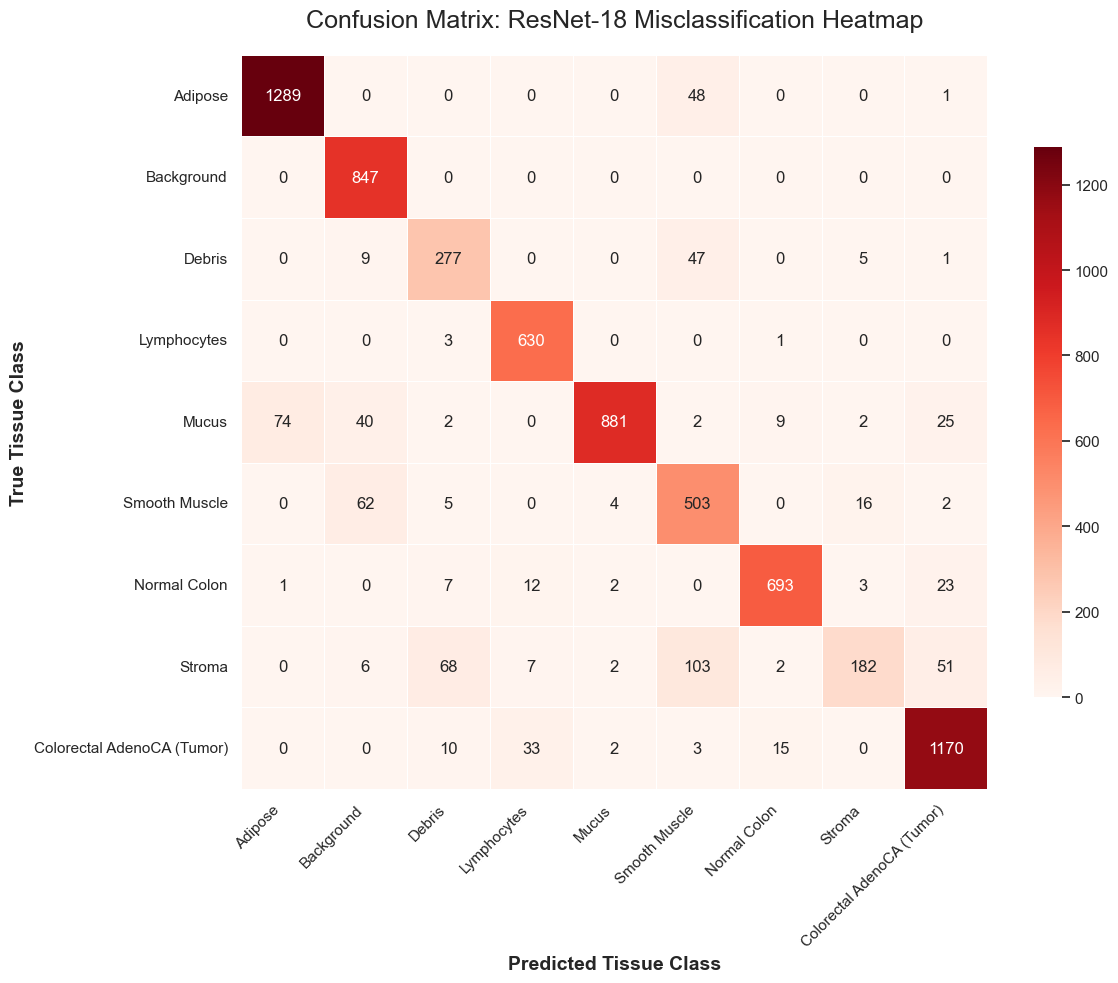

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(12, 10))

class_names = [tissue_labels[i] for i in range(9)]

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Reds',
    xticklabels=class_names, 
    yticklabels=class_names,
    linewidths=.5,
    cbar_kws={"shrink": .75}
)

plt.title('Confusion Matrix: ResNet-18 Misclassification Heatmap', fontsize=18, pad=20)
plt.ylabel('True Tissue Class', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Tissue Class', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()